# Mini-proyecto: Generación controlada de reseñas de producto en español con GPT-2

**Autores:** José Luis Realpe M., Alejandra Forero, Santiago Aristizabal, Sandra Orozco
**Curso:** Procesamiento de Lenguaje Natural — Maestría en IA Aplicada, Universidad Icesi
**Basado en:** notebook guía `1-text-generation.ipynb` (Sesión 4), Radford et al. (2018) y Keskar et al. (2019)

---

## 1. Planteamiento

### El problema

Las reseñas de producto son texto corto, con estructura fija (título + cuerpo) y una calificación de 1 a 5 estrellas que resume el sentimiento del autor. Generar reseñas plausibles con un modelo de lenguaje tiene usos legítimos (datos de prueba para sistemas de recomendación y moderación, aumento de datos para clasificadores, simuladores de atención al cliente) y un riesgo evidente: producir reseñas falsas a escala. Este caso permite estudiar las dos caras con los mismos datos y plantea tres preguntas de fondo:

- ¿Puede un modelo GPT-2 en español producir reseñas creíbles, **con la calificación que le pidamos**?
- ¿Cómo sabemos si un texto generado es bueno? En generación no existe un "accuracy" y, en el notebook guía, la evaluación consiste en leer una muestra. Aquí construimos métricas.
- ¿Se puede **detectar** el texto que generamos, y qué tanto depende eso de cómo lo decodificamos?

### Por qué GPT-2 y por qué este dataset

GPT-2 es un Transformer *decoder* entrenado para predecir el siguiente token: entrega una distribución de probabilidad $P(x_t \mid x_{<t})$ sobre todo el vocabulario y el texto se obtiene eligiendo tokens de esa distribución uno a uno. Todo lo que controla lo que el modelo escribe cabe en dos lugares: **qué distribución aprendió** (datos y fine-tuning) y **cómo elegimos de ella** (decodificación). Los experimentos se organizan alrededor de esas dos palancas.

Usamos el dataset de reseñas de Amazon en español (`mteb/amazon_reviews_multi`, config `es`: 200 000 reseñas de entrenamiento, 5 000 de validación y 5 000 de prueba, balanceadas por estrella), que ya conocemos del curso en tareas de clasificación. Aquí lo usamos al revés: la calificación pasa de ser una etiqueta que se predice a ser una **instrucción** que se le da al generador, con la técnica de *códigos de control* de CTRL (Keskar et al., 2019): cada reseña de entrenamiento lleva al inicio una línea `Calificación: N estrellas`, y en la generación escribimos esa línea para pedir una calificación. Como tenemos las estrellas reales, podemos entrenar un clasificador que actúe como **juez automático** y medir cuánto obedece el modelo, algo que con los chistes del notebook guía no era posible.

### Preguntas y experimentos

| # | Pregunta | Experimento |
|---|---|---|
| 1 | ¿El fine-tuning del notebook guía produce un generador que sabe terminar un texto? | Receta del guía frente a receta corregida (token de fin de secuencia explícito y token de relleno propio), con el modelo base como referencia |
| 2 | ¿Cómo cambia el texto según la estrategia de decodificación? | Greedy, beam search, temperatura, top-k, top-p y penalización de repetición, medidos con diversidad, repetición y copia del corpus |
| 3 | ¿Puede la calificación controlar el sentimiento del texto generado? | Códigos de control por estrellas, evaluados con el juez automático |
| 4 | ¿Se puede distinguir el texto generado del real? | Detector de reseñas sintéticas por estrategia de decodificación |

### Hipótesis

1. Con la receta del guía el modelo nunca ve el token de fin de secuencia en el entrenamiento y sus textos no terminan solos; la receta corregida lo resuelve con un costo pequeño en perplejidad.
2. Greedy y beam search producen texto repetitivo, el muestreo puro produce texto incoherente y top-p (con o sin penalización) ofrece el mejor equilibrio entre diversidad y calidad.
3. El prefijo controla el sentimiento con claridad en los extremos (1 y 5 estrellas) y con menos claridad en el centro, porque las reseñas de 3 estrellas mezclan señales de ambos polos.
4. Un detector sencillo distingue fácilmente el texto de greedy (muy repetitivo) y tiene más dificultad con el muestreo top-p, que se parece más a la distribución real.

### Diseño

| Conjunto | Tamaño (corrida completa) | Uso |
|---|---|---|
| Train, parte A | 30 000 reseñas | Fine-tuning de los generadores |
| Train, parte B | 60 000 reseñas, disjuntas de la parte A | Entrenamiento del juez (TF-IDF + regresión logística) |
| Validación | 5 000 reseñas: una muestra de 2 000 para early stopping y otra de 1 000 para perplejidad, tomadas con semillas distintas (pueden compartir reseñas) | Early stopping, perplejidad, prompts de generación y referencia del juez |
| Test | 5 000 reseñas | Textos reales para el detector |

Métricas: perplejidad y entropía sobre reseñas reales, probabilidad de terminar (EOS), fracción de textos que terminan solos, diversidad (distinct-1 y distinct-2), tasa de repetición de trigramas, copia de 8-gramas del corpus de entrenamiento, controlabilidad medida con el juez y AUC del detector.

### Qué cambia respecto al notebook guía

| Notebook guía | Este notebook |
|---|---|
| 2 419 chistes, 10 épocas | 30 000 reseñas, 4 épocas con early stopping |
| Token de relleno igual al de fin (`pad = eos`), sin EOS al entrenar | Token de relleno propio y EOS explícito al final de cada texto (experimento 1) |
| Evaluación con una muestra por modelo | Métricas sobre 100 a 500 textos por configuración, con semilla fija |
| Tres estrategias de decodificación por inspección | Siete configuraciones comparadas con métricas (experimento 2) |
| Metadatos del dataset descartados | Calificación usada como código de control (experimento 3) |
| Sin evaluación del riesgo del texto generado | Detector de texto sintético (experimento 4) |

### Referencias

- Radford et al. (2018). *Improving Language Understanding by Generative Pre-Training*. OpenAI.
- Keskar et al. (2019). *CTRL: A Conditional Transformer Language Model for Controllable Generation*. arXiv:1909.05858.
- Holtzman et al. (2020). *The Curious Case of Neural Text Degeneration* (top-p). ICLR.
- Fan et al. (2018). *Hierarchical Neural Story Generation* (top-k). ACL.
- Li et al. (2016). *A Diversity-Promoting Objective Function for Neural Conversation Models* (distinct-n). NAACL.
- Keung et al. (2020). *The Multilingual Amazon Reviews Corpus*. EMNLP.
- Tunstall, von Werra & Wolf (2022). *Natural Language Processing with Transformers*. O'Reilly (cap. 5).
- Notebook guía: https://github.com/Ohtar10/icesi-nlp (Sesion4/1-text-generation.ipynb)

## 2. Entorno

El notebook está pensado para **Google Colab con GPU** (*Entorno de ejecución → Cambiar tipo de entorno → GPU*; una L4 o una T4 sirven). La corrida completa entrena tres modelos GPT-2 de 124M parámetros y genera unos 2 700 textos; en una A100 los tres fine-tunings tomaron cerca de 12 minutos en total (unos 4 minutos por modelo) y la corrida completa cerca de media hora; en L4 estimamos entre 40 y 60 minutos, y algo más en T4. Con `QUICK_MODE = True` la corrida baja a unos 10 minutos con menos datos y menos generaciones, útil para verificar que todo funciona antes de la corrida completa (los números de esa versión no son comparables). Sin GPU el notebook activa `QUICK_MODE` solo.

Los modelos ajustados se guardan en Google Drive (`MyDrive/nlp_tarea4_checkpoints`, unos 0.5 GB por modelo). Si Colab se desconecta, al volver a ejecutar las celdas de entrenamiento los modelos se cargan desde Drive en vez de entrenarse de nuevo.

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f'Ejecutando en Colab: {IN_COLAB}')

Ejecutando en Colab: True


In [2]:
if IN_COLAB:
    # torchvision de Colab no se usa aquí y suele dar conflictos con versiones recientes de transformers (igual que en el notebook guía)
    !pip uninstall -y -q torchvision
    !pip install -q datasets transformers accelerate ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.7 MB/s eta 0:00:00


In [3]:
import os, re, time, math, json, shutil, random, logging
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import Dataset
import transformers
from transformers import (AutoTokenizer, AutoModelForCausalLM, Trainer, TrainingArguments,
                          DataCollatorForLanguageModeling, EarlyStoppingCallback, set_seed)
from huggingface_hub import hf_hub_download

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from scipy.stats import spearmanr

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
transformers.utils.logging.set_verbosity_error()
logging.getLogger('transformers').setLevel(logging.ERROR)
sns.set_theme(style='whitegrid')

SEED = 42
set_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
HAS_GPU = DEVICE == 'cuda'
USE_BF16 = HAS_GPU and torch.cuda.is_bf16_supported()      # L4 soporta bf16; T4 usa fp16
USE_FP16 = HAS_GPU and not USE_BF16

QUICK_MODE = False          # True: corrida rápida de verificación (menos datos, 1 época, menos generaciones)
if not HAS_GPU:
    QUICK_MODE = True

MODEL_NAME = 'mrm8488/spanish-gpt2'                 # GPT-2 de 124M parámetros pre-entrenado en español (el del notebook guía)
if QUICK_MODE:
    TRAIN_N, JUDGE_N, VAL_N, EVAL_N, EPOCHS = 3_000, 6_000, 500, 200, 1
    N_PROMPTS, N_PER_STAR, N_DETECT = 30, 15, 60
else:
    TRAIN_N, JUDGE_N, VAL_N, EVAL_N, EPOCHS = 30_000, 60_000, 2_000, 1_000, 4
    N_PROMPTS, N_PER_STAR, N_DETECT = 100, 100, 400
BATCH_SIZE = 32 if HAS_GPU else 8
LR = 5e-5
PROMPT_LEN = 4               # tokens reales con los que arranca cada generación libre
MAX_NEW = 80                 # tokens nuevos por generación

# Los modelos ajustados se guardan en Drive para sobrevivir a una desconexión de Colab
CKPT_ROOT = 'checkpoints_gen'
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        CKPT_ROOT = '/content/drive/MyDrive/nlp_tarea4_checkpoints'
    except Exception as e:
        print('Drive no disponible, se usa el disco local de la sesión:', e)
CKPT_DIR = os.path.join(CKPT_ROOT, 'quick' if QUICK_MODE else 'full')
os.makedirs(CKPT_DIR, exist_ok=True)

print(f'Dispositivo: {DEVICE}' + (f' ({torch.cuda.get_device_name(0)})' if HAS_GPU else '') + f' | QUICK_MODE={QUICK_MODE}')
print(f'transformers {transformers.__version__} | train generadores: {TRAIN_N} | juez: {JUDGE_N} | épocas: {EPOCHS} | batch: {BATCH_SIZE} | lr: {LR}')

Mounted at /content/drive
Dispositivo: cuda (NVIDIA A100-SXM4-80GB) | QUICK_MODE=False
transformers 5.16.1 | train generadores: 30000 | juez: 60000 | épocas: 4 | batch: 32 | lr: 5e-05


## 3. Datos

Descargamos los tres archivos `.jsonl` del Hub. El texto de cada reseña es `título\n\ncuerpo` y la calificación va de 0 a 4 en la columna `label` (estrellas − 1). Para el juez agrupamos las estrellas en tres clases (1–2 negativo, 3 neutro, 4–5 positivo). El train se baraja con semilla fija y se parte en dos bloques **disjuntos**: la parte A entrena los generadores y la parte B entrena el juez, de modo que el juez nunca vio los textos con los que se ajustó el generador.

In [4]:
def download_split(split):
    return hf_hub_download(repo_id='mteb/amazon_reviews_multi', repo_type='dataset', filename=f'es/{split}.jsonl')

def load_split(split):
    df = pd.read_json(download_split(split), lines=True)
    df['stars'] = df['label'] + 1
    df['sentiment'] = np.where(df['stars'] <= 2, 0, np.where(df['stars'] == 3, 1, 2))
    return df[['text', 'stars', 'sentiment']]

train_df, val_df, test_df = load_split('train'), load_split('validation'), load_split('test')
ID2SENT = {0: 'negativo', 1: 'neutro', 2: 'positivo'}
STAR2CLS = {1: 0, 2: 0, 3: 1, 4: 2, 5: 2}

train_pool = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
gen_df   = train_pool.iloc[:TRAIN_N]                              # parte A: entrena los generadores
judge_df = train_pool.iloc[TRAIN_N:TRAIN_N + JUDGE_N]             # parte B: entrena el juez
val_sub  = val_df.sample(min(VAL_N, len(val_df)), random_state=SEED)          # early stopping
val_lm   = val_df.sample(min(EVAL_N, len(val_df)), random_state=SEED + 1)     # perplejidad, entropía y P(EOS)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}  ->  generadores: {len(gen_df)} | juez: {len(judge_df)}')
print(train_df['sentiment'].map(ID2SENT).value_counts(normalize=True).round(3).to_dict())
train_df.head(3)

es/train.jsonl: reconstructing file:   0%|          |  0.00B / 48.7MB            

es/train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

Train: 200000 | Val: 5000 | Test: 5000  ->  generadores: 30000 | juez: 60000
{'negativo': 0.4, 'positivo': 0.4, 'neutro': 0.2}


,text,stars,sentiment
0,television Nevir\n\nNada bueno se me fue ka pa...,1,0
1,Dinero tirado a la basura con esta compra\n\nH...,1,0
2,solo llega una unidad cuando te obligan a comp...,1,0


## 4. Análisis exploratorio

Cada análisis responde a una decisión del generador: cómo se reparten las calificaciones (¿hay que balancear el control?), cuánto miden las reseñas en tokens de GPT-2 (longitud máxima de entrenamiento y de generación), qué vocabulario distingue a una reseña de 1 estrella de una de 5 (lo que el prefijo tendría que aprender a activar) y qué tan repetitivo es el corpus (lo que el modelo tenderá a reproducir).

### 4.1 Calificaciones y estructura de las reseñas

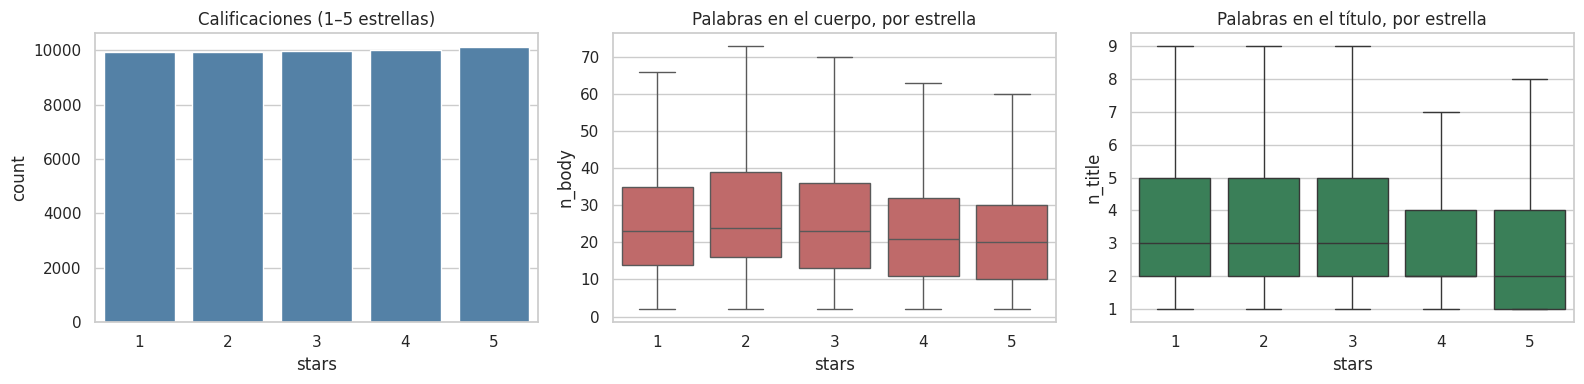

Clases: {'positivo': 0.403, 'negativo': 0.398, 'neutro': 0.199}
Reseñas con título y cuerpo: 100.0%
Mediana de palabras por estrella (título / cuerpo):
stars       1     2     3     4     5
n_title   3.0   3.0   3.0   2.0   2.0
n_body   23.0  24.0  23.0  21.0  20.0
Palabras por reseña: mediana 25, p95 76


In [5]:
eda = train_df.sample(min(50_000, len(train_df)), random_state=SEED).copy()
parts = eda['text'].str.split('\n\n', n=1, expand=True)
eda['title'], eda['body'] = parts[0], parts[1].fillna('')
eda['n_title'] = eda['title'].str.split().str.len()
eda['n_body'] = eda['body'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=eda, x='stars', ax=axes[0], color='steelblue'); axes[0].set_title('Calificaciones (1–5 estrellas)')
sns.boxplot(data=eda, x='stars', y='n_body', ax=axes[1], showfliers=False, color='indianred'); axes[1].set_title('Palabras en el cuerpo, por estrella')
sns.boxplot(data=eda, x='stars', y='n_title', ax=axes[2], showfliers=False, color='seagreen'); axes[2].set_title('Palabras en el título, por estrella')
plt.tight_layout(); plt.show()

print('Clases:', eda['sentiment'].map(ID2SENT).value_counts(normalize=True).round(3).to_dict())
print(f'Reseñas con título y cuerpo: {(eda["body"].str.len() > 0).mean()*100:.1f}%')
print('Mediana de palabras por estrella (título / cuerpo):')
print(eda.groupby('stars')[['n_title', 'n_body']].median().T.to_string())
print(f'Palabras por reseña: mediana {eda["text"].str.split().str.len().median():.0f}, p95 {eda["text"].str.split().str.len().quantile(.95):.0f}')

**Hallazgos:** las calificaciones están balanceadas por construcción (20 % cada una); al agruparlas en tres clases queda 40 / 20 / 40, y para el control por estrellas eso significa que cada nivel se entrena con el mismo número de ejemplos. Todas las reseñas traen título y cuerpo, y las reseñas son **cortas** (mediana de 25 palabras, percentil 95 de 76), lo que permite un contexto máximo pequeño y generaciones baratas. La extensión cambia poco con la calificación: la mediana del cuerpo es de 23 a 24 palabras en 1, 2 y 3 estrellas, 21 en 4 y 20 en 5, y la del título baja de 3 a 2 palabras en 4 y 5 estrellas; las reseñas positivas son algo más cortas.

### 4.2 Longitud en tokens de GPT-2 y elección de `MAX_LEN`

GPT-2 usa BPE a nivel de bytes: no hay tokens desconocidos, y el tokenizer de `spanish-gpt2` fue entrenado con texto en español. Medimos la longitud en tokens, cuántos tokens necesita una palabra con y sin acento (para comprobar si las tildes fragmentan más), y fijamos `MAX_LEN` en el percentil 95 (redondeado a múltiplo de 8): el resto de las reseñas se trunca al entrenar, y esas reseñas truncadas no reciben token de fin, para que el modelo aprenda a terminar solo donde una reseña realmente termina.

config.json:   0%|          | 0.00/883 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/226 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/846k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/505k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.45M [00:00<?, ?B/s]

Percentiles de tokens por reseña: {50: 33, 75: 49, 90: 74, 95: 94, 99: 153}
MAX_LEN = 96 -> se truncan 4.7% de las reseñas
Tokens por palabra: 1.28
Tokens por palabra frecuente: con tilde/ñ 1.12 (401 palabras) | sin tilde 1.20 (2599 palabras)


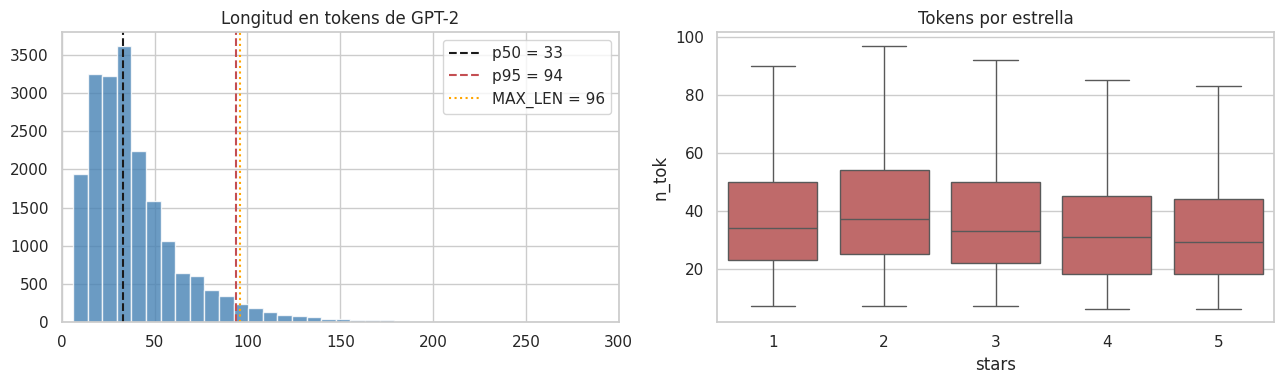

In [6]:
tok_eda = AutoTokenizer.from_pretrained(MODEL_NAME)
sample = eda.sample(min(20_000, len(eda)), random_state=SEED).copy()
ids_sample = tok_eda(list(sample['text']), add_special_tokens=False)['input_ids']
sample['n_tok'] = [len(x) for x in ids_sample]
sample['n_words'] = sample['text'].str.split().str.len()

pct = {p: int(np.percentile(sample['n_tok'], p)) for p in [50, 75, 90, 95, 99]}
MAX_LEN = int(min(160, np.ceil(pct[95] / 8) * 8))
print('Percentiles de tokens por reseña:', pct)
print(f'MAX_LEN = {MAX_LEN} -> se truncan {(sample["n_tok"] > MAX_LEN).mean()*100:.1f}% de las reseñas')
print(f'Tokens por palabra: {sample["n_tok"].sum() / sample["n_words"].sum():.2f}')

# Fragmentación de palabras con y sin caracteres no ASCII (tildes, ñ)
vocab_words = pd.Series(' '.join(sample['text'].head(5000)).lower().split()).str.strip('.,;:!?¡¿()"').value_counts()
vocab_words = vocab_words[vocab_words.index.str.len() > 2].head(3000).index
acc = [w for w in vocab_words if re.search(r'[áéíóúñü]', w)]
plain = [w for w in vocab_words if not re.search(r'[áéíóúñü]', w)]
frag = lambda ws: np.mean([len(tok_eda(' ' + w, add_special_tokens=False)['input_ids']) for w in ws])
print(f'Tokens por palabra frecuente: con tilde/ñ {frag(acc):.2f} ({len(acc)} palabras) | sin tilde {frag(plain):.2f} ({len(plain)} palabras)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sample['n_tok'], bins=60, color='steelblue', alpha=.8)
for p, c in [(50, 'k'), (95, 'r')]: axes[0].axvline(pct[p], color=c, ls='--', label=f'p{p} = {pct[p]}')
axes[0].axvline(MAX_LEN, color='orange', ls=':', label=f'MAX_LEN = {MAX_LEN}'); axes[0].set_xlim(0, 300); axes[0].legend(); axes[0].set_title('Longitud en tokens de GPT-2')
sns.boxplot(data=sample, x='stars', y='n_tok', ax=axes[1], showfliers=False, color='indianred'); axes[1].set_title('Tokens por estrella')
plt.tight_layout(); plt.show()

**Decisión y lectura:** la mediana de una reseña es de 33 tokens y el percentil 95 de 94; `MAX_LEN` queda en **96**, con 4.7 % de reseñas truncadas (esas no reciben token de fin). El tokenizer produce 1.28 tokens por palabra. Las palabras con tilde (401 de 3 000 muestreadas) necesitan **1.12** tokens y las sin tilde **1.20**: en este tokenizer las tildes no fragmentan más el texto, y la hipótesis contraria queda descartada para el vocabulario frecuente. Como el contexto de GPT-2 admite 1 024 tokens y las reseñas ocupan una fracción pequeña, el costo del entrenamiento depende sobre todo del tamaño del batch.

### 4.3 Vocabulario que distingue a 1 y 5 estrellas y arranque de los títulos

Si el prefijo `Calificación: N estrellas` funciona, el modelo tiene que aprender a activar un vocabulario distinto según N. Medimos qué palabras separan a las reseñas de 1 y de 5 estrellas con la razón de log-odds sobre frecuencia de documento (positiva: más propia de 5 estrellas), y qué palabras abren los títulos en cada calificación.

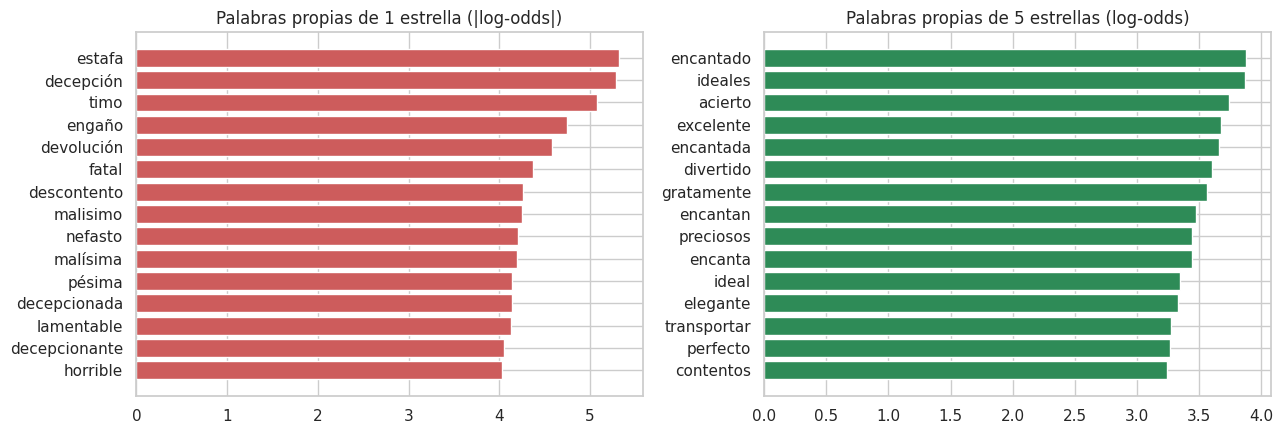

Primera palabra del título, las 6 más frecuentes por calificación:
  1★   2★      3★      4★        5★
  no   no      no   buena       muy
mala  muy    bien     muy     buena
 muy   se     muy    buen  perfecto
 mal mala    buen    bien      buen
  se   la   buena  cumple excelente
  el   el regular calidad      todo


In [7]:
sub = eda[eda['stars'].isin([1, 5])].groupby('stars').head(15_000)
cv = CountVectorizer(min_df=max(5, len(sub) // 3000), token_pattern=r'(?u)\b\w\w+\b', lowercase=True, binary=True)
X = cv.fit_transform(sub['text'])
is5 = (sub['stars'].values == 5)
df5 = np.asarray(X[is5].sum(0)).ravel() + 1
df1 = np.asarray(X[~is5].sum(0)).ravel() + 1
log_odds = np.log(df5 / is5.sum()) - np.log(df1 / (~is5).sum())
terms = np.array(cv.get_feature_names_out()); order = np.argsort(log_odds)
top1, top5 = order[:15], order[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(terms[top1][::-1], -log_odds[top1][::-1], color='indianred'); axes[0].set_title('Palabras propias de 1 estrella (|log-odds|)')
axes[1].barh(terms[top5][::-1], log_odds[top5][::-1], color='seagreen'); axes[1].set_title('Palabras propias de 5 estrellas (log-odds)')
plt.tight_layout(); plt.show()

first_word = eda['title'].str.split().str[0].str.lower()
print('Primera palabra del título, las 6 más frecuentes por calificación:')
print(pd.DataFrame({f'{s}★': first_word[eda['stars'] == s].value_counts().head(6).index.tolist() for s in range(1, 6)}).to_string(index=False))

**Lectura:** el vocabulario polar separa las calificaciones desde la primera palabra del título. En 1 estrella los títulos arrancan con *no*, *mala*, *muy*, *mal*; en 3 estrellas con *no*, *bien*, *muy*, *buen*; en 5 estrellas con *muy*, *buena*, *perfecto*, *buen*, *excelente*. La palabra *no* aparece entre las primeras palabras de 1 y de 3 estrellas, así que el primer token por sí solo distingue poco y el prefijo tiene que influir en toda la secuencia. Esta es la distribución del primer token que inspeccionamos en el experimento 3.

### 4.4 Fórmulas repetidas y duplicados

Un modelo entrenado sobre texto muy formulaico tiende a producir texto formulaico, y las métricas de diversidad y de copia del corpus solo se interpretan frente a la base real. Medimos qué fracción de las reseñas contiene frases comunes, qué títulos se repiten y cuántas reseñas están duplicadas.

In [8]:
frases = ['calidad precio', 'calidad-precio', 'lo recomiendo', 'muy bueno', 'no funciona', 'cumple', 'llegó', 'no lo recomiendo', 'recomendable']
low = eda['text'].str.lower()
print('Fracción de reseñas que contienen cada frase:')
print(pd.Series({f: low.str.contains(f, regex=False).mean() for f in frases}).sort_values(ascending=False).round(3).to_string())
print('\nTítulos más repetidos:')
print(eda['title'].str.lower().value_counts().head(8).to_string())
print(f'\nReseñas duplicadas (texto idéntico) en el train completo: {train_df["text"].duplicated().mean()*100:.2f}%')

Fracción de reseñas que contienen cada frase:
cumple              0.056
llegó               0.036
lo recomiendo       0.031
calidad precio      0.031
recomendable        0.030
no funciona         0.026
muy bueno           0.018
no lo recomiendo    0.016
calidad-precio      0.009

Títulos más repetidos:
title
bien             553
perfecto         513
buen producto    451
regular          350
buena compra     328
mala calidad     313
correcto         241
buena calidad    228

Reseñas duplicadas (texto idéntico) en el train completo: 0.14%


**Lectura:** las reseñas son cortas (mediana de 25 palabras, percentil 95 de 76) y muy formulaicas. Las fórmulas más frecuentes son *cumple* (5.6 % de las reseñas), *llegó* (3.6 %), *lo recomiendo* (3.1 %), *calidad precio* (3.1 %) y *recomendable* (3.0 %); entre los títulos, *bien* (553 veces), *perfecto* (513), *buen producto* (451) y *regular* (350) se repiten decenas de veces. Los duplicados exactos son 0.14 % del train. Parte del solapamiento con el corpus de entrenamiento que mediremos después viene de estas fórmulas, que cualquier reseña real también repite; la línea base de copia de 8-gramas en reseñas reales es 0.08.

## 5. El modelo y un detalle del notebook guía

El modelo es `mrm8488/spanish-gpt2` (12 bloques *decoder*, 12 cabezas, d = 768, 124M parámetros). Como es causal, la pérdida de entrenamiento es la de predecir cada token a partir de los anteriores; el `DataCollatorForLanguageModeling` con `mlm=False` construye las etiquetas copiando `input_ids` y poniendo `-100` (ignorar) donde el token es el de relleno.

El notebook guía define `tokenizer.pad_token = tokenizer.eos_token`. GPT-2 no trae token de relleno y esa es la salida habitual, pero tiene una consecuencia: si el relleno y el fin de secuencia son el mismo token, el collator ignora **todos** los EOS, incluso los que sí forman parte del texto. Además, el tokenizer de GPT-2 no agrega EOS al final de cada texto, así que la receta del guía nunca enseña al modelo a terminar. Comprobamos qué hace el collator con un EOS real en las dos configuraciones: relleno igual a EOS (guía) y relleno propio.

In [9]:
def load_tok(kind):
    '''kind="guide": relleno = EOS (como el notebook guía). kind="fixed": token de relleno propio, distinto de EOS.'''
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)
    if kind == 'fixed':
        tok.add_special_tokens({'pad_token': '<|pad|>'})
    elif tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return tok

def load_lm(kind):
    tok = load_tok(kind)
    model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
    model.resize_token_embeddings(len(tok))          # solo cambia si se agregó un token (los embeddings nuevos parten de la media de los existentes)
    model.config.pad_token_id = tok.pad_token_id
    return tok, model.float().to(DEVICE)

def collate_demo(tok):
    textos = ['Muy buen producto', 'Excelente calidad y llegó rápido']
    feats = [{'input_ids': tok(t, add_special_tokens=False)['input_ids'] + [tok.eos_token_id]} for t in textos]
    b = DataCollatorForLanguageModeling(tok, mlm=False)(feats)
    print(f'  pad_token_id = {tok.pad_token_id} | eos_token_id = {tok.eos_token_id}')
    for i, f in enumerate(feats):
        pos = len(f['input_ids']) - 1
        lab = b['labels'][i][pos].item()
        print(f'  secuencia {i}: EOS en la posición {pos} -> etiqueta {lab} | ¿el EOS entra en la pérdida? {lab != -100}')

_t = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer original: pad_token = {_t.pad_token!r} | eos_token = {_t.eos_token!r}')
print('Receta del guía (relleno = EOS):'); collate_demo(load_tok('guide'))
print('Receta corregida (relleno propio):'); collate_demo(load_tok('fixed'))

Tokenizer original: pad_token = None | eos_token = '<|endoftext|>'
Receta del guía (relleno = EOS):
  pad_token_id = 50265 | eos_token_id = 50265
  secuencia 0: EOS en la posición 3 -> etiqueta -100 | ¿el EOS entra en la pérdida? False
  secuencia 1: EOS en la posición 5 -> etiqueta -100 | ¿el EOS entra en la pérdida? False
Receta corregida (relleno propio):
  pad_token_id = 50266 | eos_token_id = 50265
  secuencia 0: EOS en la posición 3 -> etiqueta 50265 | ¿el EOS entra en la pérdida? True
  secuencia 1: EOS en la posición 5 -> etiqueta 50265 | ¿el EOS entra en la pérdida? True


**Lectura:** el tokenizer original no tiene token de relleno (`pad_token=None`) y su token de fin es `<|endoftext|>` (id 50265). Con la receta del guía (`pad = eos`, id 50265) la etiqueta del EOS queda en **−100** y la pérdida lo ignora; con un relleno propio (id 50266) la etiqueta del EOS es **50265** y la pérdida lo supervisa. Con la receta del guía el modelo no recibe ninguna señal sobre cuándo terminar una reseña.

## 6. Utilidades: datos, evaluación, generación y métricas

Definimos las funciones que se reutilizan en todos los experimentos. Las métricas de texto se calculan sobre palabras (minúsculas, sin puntuación):

| Métrica | Qué mide |
|---|---|
| Perplejidad | $\exp$ de la pérdida media sobre reseñas reales reservadas (menor es mejor); no incluye el primer token ni el EOS, para comparar modelos con y sin EOS |
| Entropía | Incertidumbre media (en nats) de la distribución del siguiente token |
| P(EOS al final) | Probabilidad que el modelo asigna a terminar justo donde una reseña real termina |
| Termina solo | Fracción de textos generados que emiten EOS antes de agotar `MAX_NEW` tokens |
| distinct-1 / distinct-2 | Fracción de unigramas / bigramas únicos sobre el total generado (mayor es más diverso) |
| Repetición | Fracción media de trigramas repetidos dentro de un mismo texto |
| Copia 8-gramas | Fracción de textos que comparten algún 8-grama de palabras con el corpus de entrenamiento |

In [10]:
class TokDataset(Dataset):
    def __init__(self, seqs): self.seqs = seqs
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i): return {'input_ids': self.seqs[i]}

def encode_texts(tok, texts, max_len, add_eos):
    '''Tokeniza y trunca a max_len. Con add_eos, agrega EOS solo a las reseñas que caben completas: las truncadas
    quedan sin EOS para que el modelo aprenda a terminar donde una reseña realmente termina.'''
    enc = tok(list(texts), add_special_tokens=False)['input_ids']
    out, n_eos = [], 0
    for ids in enc:
        if add_eos and len(ids) <= max_len - 1:
            ids = ids + [tok.eos_token_id]; n_eos += 1
        else:
            ids = ids[:max_len]
        out.append(ids)
    return out, n_eos

@torch.no_grad()
def eval_lm(model, tok, texts, max_len=None, bs=16):
    '''Perplejidad, entropía media y P(EOS) al final natural de la reseña, sobre reseñas reales.'''
    max_len = max_len or MAX_LEN
    model.eval()
    seqs = [s for s in encode_texts(tok, texts, max_len, add_eos=False)[0] if len(s) > 1]
    nll_sum = ent_sum = n_tok = 0.0
    peos = []
    for i in range(0, len(seqs), bs):
        chunk = seqs[i:i + bs]; L = max(map(len, chunk))
        ids = torch.full((len(chunk), L), tok.pad_token_id, dtype=torch.long); att = torch.zeros((len(chunk), L), dtype=torch.long)
        for j, s in enumerate(chunk):
            ids[j, :len(s)] = torch.tensor(s); att[j, :len(s)] = 1
        ids, att = ids.to(DEVICE), att.to(DEVICE)
        logits = model(input_ids=ids, attention_mask=att).logits.float()
        logp = torch.log_softmax(logits[:, :-1], -1)
        tgt, m = ids[:, 1:], att[:, 1:].bool()
        nll = -logp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
        ent = -(logp.exp() * logp).sum(-1)
        nll_sum += nll[m].sum().item(); ent_sum += ent[m].sum().item(); n_tok += m.sum().item()
        for j, s in enumerate(chunk):
            if len(s) < max_len:      # la reseña terminó antes del corte: el siguiente token "correcto" sería EOS
                peos.append(torch.softmax(logits[j, len(s) - 1], -1)[tok.eos_token_id].item())
    return {'perplejidad': math.exp(nll_sum / n_tok), 'entropia': ent_sum / n_tok, 'P(EOS al final)': float(np.mean(peos)) if peos else float('nan')}

@torch.no_grad()
def generate_batch(model, tok, prompt_ids, max_new=None, bs=50, **gen_kw):
    '''prompt_ids: lista de listas de ids, todas con la misma longitud. Devuelve textos (cortados en el primer EOS)
    y una lista de booleanos que indica si el texto terminó solo.'''
    max_new = max_new or MAX_NEW
    model.eval(); texts, finished = [], []
    for i in range(0, len(prompt_ids), bs):
        inp = torch.tensor(prompt_ids[i:i + bs], device=DEVICE)
        suppress = [tok.pad_token_id] if tok.pad_token_id != tok.eos_token_id else None    # el relleno propio nunca debe aparecer en el texto
        out = model.generate(input_ids=inp, attention_mask=torch.ones_like(inp), max_new_tokens=max_new,
                             pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id, suppress_tokens=suppress, **gen_kw)
        for row in out.tolist():
            gen = row[inp.shape[1]:]
            if tok.eos_token_id in gen:
                gen = gen[:gen.index(tok.eos_token_id)]; finished.append(True)
            else:
                finished.append(False)
            texts.append(tok.decode(row[:inp.shape[1]] + gen))
    return texts, finished

@torch.no_grad()
def next_token_top(model, tok, text, k=6):
    model.eval()
    ids = torch.tensor([tok_eda(text, add_special_tokens=False)['input_ids']], device=DEVICE)
    p = torch.softmax(model(input_ids=ids).logits[0, -1].float(), -1)
    top = p.topk(k)
    return [('<EOS>' if i == tok.eos_token_id else repr(tok.decode([i])), round(v, 3)) for v, i in zip(top.values.tolist(), top.indices.tolist())]

def finetune(name, tok, model, train_seqs, val_seqs):
    '''Entrena con Trainer (misma configuración para todas las corridas) o carga el modelo guardado si ya existe.'''
    ckpt = os.path.join(CKPT_DIR, name)
    if os.path.exists(os.path.join(ckpt, 'config.json')):
        model = AutoModelForCausalLM.from_pretrained(ckpt).float().to(DEVICE)
        hist = json.load(open(os.path.join(ckpt, 'log_history.json')))
        print(f'[{name}] modelo cargado de {ckpt}')
        return model, hist
    args = TrainingArguments(output_dir=f'./runs/{name}', num_train_epochs=EPOCHS, learning_rate=LR, weight_decay=0.01,
                             per_device_train_batch_size=BATCH_SIZE, per_device_eval_batch_size=BATCH_SIZE,
                             eval_strategy='epoch', save_strategy='epoch', save_total_limit=1, load_best_model_at_end=True,
                             metric_for_best_model='eval_loss', greater_is_better=False, logging_strategy='epoch',
                             report_to='none', bf16=USE_BF16, fp16=USE_FP16, seed=SEED)
    trainer = Trainer(model=model, args=args, train_dataset=TokDataset(train_seqs), eval_dataset=TokDataset(val_seqs),
                      data_collator=DataCollatorForLanguageModeling(tok, mlm=False),
                      callbacks=[EarlyStoppingCallback(early_stopping_patience=1)])
    t0 = time.time(); trainer.train(); el = time.time() - t0
    hist = list(trainer.state.log_history) + [{'train_time_s': el}]
    model = trainer.model
    model.save_pretrained(ckpt); json.dump(hist, open(os.path.join(ckpt, 'log_history.json'), 'w'))
    del trainer; shutil.rmtree(f'./runs/{name}', ignore_errors=True)
    if HAS_GPU: torch.cuda.empty_cache()
    print(f'[{name}] entrenado en {el/60:.1f} min')
    return model, hist

In [11]:
WORD = re.compile(r'\w+', re.UNICODE)
words = lambda t: WORD.findall(t.lower())

def distinct_n(texts, n):
    total, uniq = 0, set()
    for t in texts:
        w = words(t); g = [tuple(w[i:i + n]) for i in range(len(w) - n + 1)]
        total += len(g); uniq.update(g)
    return len(uniq) / max(total, 1)

def repetition_rate(texts, n=3):
    rates = []
    for t in texts:
        w = words(t); g = [tuple(w[i:i + n]) for i in range(len(w) - n + 1)]
        if g: rates.append(1 - len(set(g)) / len(g))
    return float(np.mean(rates)) if rates else 0.0

def ngram_hashes(text, n=8):
    w = words(text)
    return {hash(tuple(w[i:i + n])) for i in range(len(w) - n + 1)}

TRAIN_8G = set()
for t in gen_df['text']: TRAIN_8G |= ngram_hashes(t)
copy_rate = lambda texts: float(np.mean([bool(ngram_hashes(t) & TRAIN_8G) for t in texts]))

def text_metrics(texts, finished=None):
    d = {'distinct1': distinct_n(texts, 1), 'distinct2': distinct_n(texts, 2), 'repeticion': repetition_rate(texts),
         'palabras': float(np.mean([len(words(t)) for t in texts])), 'copia_8gram': copy_rate(texts)}
    d['termina_solo'] = float(np.mean(finished)) if finished is not None else float('nan')
    return d

def build_prompts(df, n, seed=SEED):
    '''Arranque real de n reseñas (PROMPT_LEN tokens) y su continuación real truncada a la misma longitud que las generadas.'''
    prompts, refs = [], []
    for t in df.sample(frac=1.0, random_state=seed)['text']:
        ids = tok_eda(t, add_special_tokens=False)['input_ids']
        if len(ids) >= PROMPT_LEN + 8:
            prompts.append(ids[:PROMPT_LEN]); refs.append(tok_eda.decode(ids[:PROMPT_LEN + MAX_NEW]))
        if len(prompts) == n: break
    return prompts, refs

PROMPTS, REAL_REF = build_prompts(val_df, N_PROMPTS)

# Estrategias de decodificación del experimento 2. top_k=0 desactiva el top-k=50 que HuggingFace activa por defecto al muestrear.
DECODING = {
    'greedy':              dict(do_sample=False),
    'beam4':               dict(do_sample=False, num_beams=4, early_stopping=True),
    'temp0.7':             dict(do_sample=True, temperature=0.7, top_k=0, top_p=1.0),
    'temp1.0 (puro)':      dict(do_sample=True, temperature=1.0, top_k=0, top_p=1.0),
    'top-k 50':            dict(do_sample=True, temperature=1.0, top_k=50, top_p=1.0),
    'top-p 0.9':           dict(do_sample=True, temperature=1.0, top_k=0, top_p=0.9),
    'top-p 0.9 + rep 1.2': dict(do_sample=True, temperature=1.0, top_k=0, top_p=0.9, repetition_penalty=1.2),
}
GEN_TOPP = DECODING['top-p 0.9']
print(f'{len(PROMPTS)} prompts de {PROMPT_LEN} tokens | ejemplo: {tok_eda.decode(PROMPTS[0])!r}')
print('Referencia real (mismas reseñas, misma longitud):', {k: round(v, 3) for k, v in text_metrics(REAL_REF).items() if k != 'termina_solo'})

100 prompts de 4 tokens | ejemplo: 'distinto tono de'
Referencia real (mismas reseñas, misma longitud): {'distinct1': 0.33, 'distinct2': 0.811, 'repeticion': 0.012, 'palabras': 31.31, 'copia_8gram': 0.08}


### El juez automático

Para medir si el texto generado tiene el sentimiento pedido necesitamos un evaluador independiente del generador. Entrenamos sobre la parte B del train dos regresiones logísticas con TF-IDF de palabras y bigramas: una de **tres clases** (negativo, neutro, positivo, con pesos de clase balanceados) y una de **cinco estrellas** cuya salida se convierte en una calificación esperada (promedio de las estrellas ponderado por su probabilidad). El juez es imperfecto, así que también lo evaluamos sobre reseñas reales de validación: esa exactitud es el techo de la controlabilidad que podemos medir.

In [12]:
t0 = time.time()
judge_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=100_000, sublinear_tf=True)
Xj = judge_vec.fit_transform(judge_df['text'])
judge3 = LogisticRegression(max_iter=1000, C=3.0, class_weight='balanced').fit(Xj, judge_df['sentiment'])
judge5 = LogisticRegression(max_iter=1000, C=3.0).fit(Xj, judge_df['stars'])
judge_class = lambda texts: judge3.predict(judge_vec.transform(texts))
judge_stars = lambda texts: judge5.predict_proba(judge_vec.transform(texts)) @ judge5.classes_
print(f'Juez entrenado en {time.time()-t0:.0f}s')

pred3, exp5 = judge_class(val_df['text']), judge_stars(val_df['text'])
print(f'Juez sobre reseñas reales de validación: exactitud 3 clases {accuracy_score(val_df["sentiment"], pred3):.3f} | '
      f'F1 macro {f1_score(val_df["sentiment"], pred3, average="macro"):.3f} | error medio en estrellas {np.abs(exp5 - val_df["stars"]).mean():.2f}')
real_judge = pd.DataFrame({'stars': val_df['stars'], 'clase_ok': pred3 == val_df['stars'].map(STAR2CLS), 'estrellas_juez': exp5})
JUDGE_REAL = real_judge.groupby('stars').agg(exactitud=('clase_ok', 'mean'), estrellas_juez=('estrellas_juez', 'mean')).round(3)
JUDGE_REAL

Juez entrenado en 109s
Juez sobre reseñas reales de validación: exactitud 3 clases 0.741 | F1 macro 0.700 | error medio en estrellas 0.60


,exactitud,estrellas_juez
stars,,
1,0.916,1.667
2,0.667,2.295
3,0.503,2.939
4,0.712,3.790
5,0.905,4.271


## 7. Experimento 1: fine-tuning con la receta del guía y con la receta corregida

**Pregunta:** ¿qué le pasa a un generador ajustado con la receta del guía (relleno = EOS, sin EOS en los datos) frente a uno ajustado con EOS explícito y relleno propio?

**Qué cambia entre las dos corridas:** solo el tratamiento del fin de secuencia. Ambas usan las mismas reseñas, los mismos hiperparámetros (lr 5e-5, batch 32, hasta 4 épocas con early stopping por pérdida de validación con paciencia 1) y la misma semilla. Como referencia se incluye el modelo base sin ajustar. Las tres se comparan con las mismas funciones de evaluación sobre reseñas reales reservadas.

In [13]:
set_seed(SEED); tok_b, model_b = load_lm('guide')     # base sin ajustar (misma configuración de tokens que el guía)
set_seed(SEED); tok_g, model_g = load_lm('guide')     # se ajustará con la receta del guía
set_seed(SEED); tok_f, model_f = load_lm('fixed')     # se ajustará con la receta corregida

texts_tr, texts_va = list(gen_df['text']), list(val_sub['text'])
seq_g_tr, _ = encode_texts(tok_g, texts_tr, MAX_LEN, add_eos=False)
seq_g_va, _ = encode_texts(tok_g, texts_va, MAX_LEN, add_eos=False)
seq_f_tr, n_eos = encode_texts(tok_f, texts_tr, MAX_LEN, add_eos=True)
seq_f_va, _ = encode_texts(tok_f, texts_va, MAX_LEN, add_eos=True)
print(f'Receta corregida: {n_eos / len(seq_f_tr) * 100:.1f}% de las reseñas de entrenamiento terminan con EOS (el resto se truncó en MAX_LEN = {MAX_LEN})')
print(f'Parámetros: {sum(p.numel() for p in model_f.parameters())/1e6:.1f}M | tokens de entrenamiento: {sum(map(len, seq_f_tr))/1e6:.2f}M')

model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Receta corregida: 95.3% de las reseñas de entrenamiento terminan con EOS (el resto se truncó en MAX_LEN = 96)
Parámetros: 124.4M | tokens de entrenamiento: 1.17M


In [14]:
model_g, hist_g = finetune('guia', tok_g, model_g, seq_g_tr, seq_g_va)

{'loss': '3.586', 'grad_norm': '2.189', 'learning_rate': '3.751e-05', 'epoch': '1'}
{'eval_loss': '3.391', 'eval_runtime': '1.315', 'eval_samples_per_second': '1521', 'eval_steps_per_second': '47.92', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.251', 'grad_norm': '2.266', 'learning_rate': '2.501e-05', 'epoch': '2'}
{'eval_loss': '3.326', 'eval_runtime': '1.315', 'eval_samples_per_second': '1520', 'eval_steps_per_second': '47.89', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.146', 'grad_norm': '1.793', 'learning_rate': '1.251e-05', 'epoch': '3'}
{'eval_loss': '3.308', 'eval_runtime': '1.329', 'eval_samples_per_second': '1505', 'eval_steps_per_second': '47.4', 'epoch': '3'}


...

{'loss': '3.089', 'grad_norm': '2.483', 'learning_rate': '1.333e-08', 'epoch': '4'}
{'eval_loss': '3.307', 'eval_runtime': '1.315', 'eval_samples_per_second': '1521', 'eval_steps_per_second': '47.91', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '217.5', 'train_samples_per_second': '551.8', 'train_steps_per_second': '17.25', 'train_loss': '3.268', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[guia] entrenado en 3.6 min


In [15]:
model_f, hist_f = finetune('corregida', tok_f, model_f, seq_f_tr, seq_f_va)

{'loss': '3.694', 'grad_norm': '2.238', 'learning_rate': '3.751e-05', 'epoch': '1'}
{'eval_loss': '3.383', 'eval_runtime': '1.448', 'eval_samples_per_second': '1382', 'eval_steps_per_second': '43.52', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.243', 'grad_norm': '2.257', 'learning_rate': '2.501e-05', 'epoch': '2'}
{'eval_loss': '3.312', 'eval_runtime': '1.436', 'eval_samples_per_second': '1393', 'eval_steps_per_second': '43.87', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '3.136', 'grad_norm': '1.78', 'learning_rate': '1.251e-05', 'epoch': '3'}
{'eval_loss': '3.292', 'eval_runtime': '1.456', 'eval_samples_per_second': '1374', 'eval_steps_per_second': '43.27', 'epoch': '3'}


...

{'loss': '3.079', 'grad_norm': '2.432', 'learning_rate': '1.333e-08', 'epoch': '4'}
{'eval_loss': '3.29', 'eval_runtime': '1.459', 'eval_samples_per_second': '1371', 'eval_steps_per_second': '43.17', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '233.7', 'train_samples_per_second': '513.4', 'train_steps_per_second': '16.05', 'train_loss': '3.288', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[corregida] entrenado en 3.9 min


### 7.1 Curvas de entrenamiento y comparación de los tres modelos

La pérdida que reporta `Trainer` no es comparable entre las dos recetas (la corregida incluye la predicción del EOS). Por eso las comparaciones de la tabla usan una evaluación común: perplejidad y entropía sobre reseñas reales reservadas, sin contar el primer token ni el EOS.

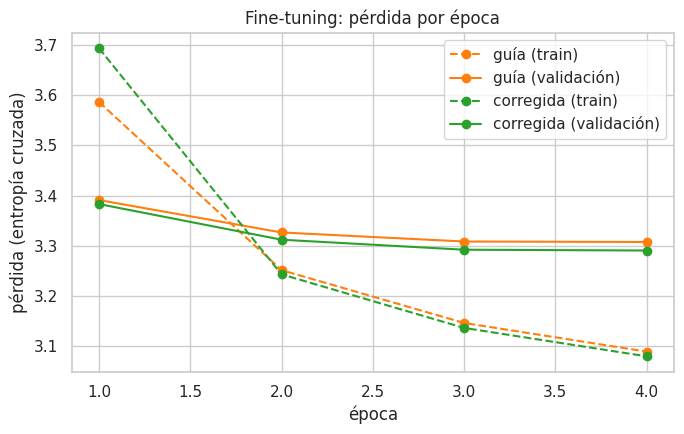

guía: épocas ejecutadas 4 | mejor pérdida de validación 3.307 en la época 4 | tiempo 3.6 min
corregida: épocas ejecutadas 4 | mejor pérdida de validación 3.290 en la época 4 | tiempo 3.9 min


In [16]:
def curves(hist):
    tr = [(h['epoch'], h['loss']) for h in hist if 'loss' in h and 'eval_loss' not in h]
    va = [(h['epoch'], h['eval_loss']) for h in hist if 'eval_loss' in h]
    return tr, va

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, hist, c in [('guía', hist_g, 'tab:orange'), ('corregida', hist_f, 'tab:green')]:
    tr, va = curves(hist)
    if tr: ax.plot(*zip(*tr), '--o', color=c, label=f'{name} (train)')
    if va: ax.plot(*zip(*va), '-o', color=c, label=f'{name} (validación)')
ax.set_xlabel('época'); ax.set_ylabel('pérdida (entropía cruzada)'); ax.set_title('Fine-tuning: pérdida por época'); ax.legend(); plt.tight_layout(); plt.show()
for name, hist in [('guía', hist_g), ('corregida', hist_f)]:
    tr, va = curves(hist)
    best = min(va, key=lambda x: x[1]) if va else None
    print(f'{name}: épocas ejecutadas {len(va)} | mejor pérdida de validación {best[1]:.3f} en la época {best[0]:.0f} | tiempo {hist[-1].get("train_time_s", float("nan"))/60:.1f} min')

In [17]:
MODELS = {'base (sin ajustar)': (model_b, tok_b), 'guía (sin EOS, pad=eos)': (model_g, tok_g), 'corregida (EOS + pad propio)': (model_f, tok_f)}
val_texts_eval = list(val_lm['text'])
rows = {}
for name, (m, t) in MODELS.items():
    r = eval_lm(m, t, val_texts_eval)
    set_seed(SEED); txt, fin = generate_batch(m, t, PROMPTS, **GEN_TOPP)
    r['termina_solo'] = float(np.mean(fin))
    rows[name] = r
tab1 = pd.DataFrame(rows).T
tab1

,perplejidad,entropia,P(EOS al final),termina_solo
base (sin ajustar),282.201177,4.502486,1.770932e-07,0.00
"guía (sin EOS, pad=eos)",29.769038,3.207538,4.914228e-09,0.00
corregida (EOS + pad propio),30.565913,3.195864,3.100549e-01,0.92


In [18]:
# Distribución del siguiente token: ¿qué cree cada modelo que sigue en medio de una reseña y al final de una?
CONTEXTOS = ['Muy buen producto', 'Muy buen producto, lo recomiendo.']
for c in CONTEXTOS:
    print(f'Contexto: {c!r}')
    for name, (m, t) in MODELS.items():
        print(f'  {name:<32}', next_token_top(m, t, c))
    print()

# Un mismo arranque, la misma semilla, tres modelos
FIXED_PROMPTS = ['Muy buena calidad', 'No funciona', 'Llegó tarde y']
for p in FIXED_PROMPTS:
    print(f'PROMPT: {p!r}')
    ids = tok_eda(p, add_special_tokens=False)['input_ids']
    for name, (m, t) in MODELS.items():
        set_seed(SEED); out, fin = generate_batch(m, t, [ids], max_new=60, **GEN_TOPP)
        print(f'  [{name}] {"(terminó solo)" if fin[0] else "(cortado por longitud)"}\n    {out[0]!r}')
    print()

Contexto: 'Muy buen producto'
  base (sin ajustar)               [("'.'", 0.57), ("','", 0.151), ("'!'", 0.086), ("' para'", 0.025), ("' de'", 0.022), ("' en'", 0.009)]
  guía (sin EOS, pad=eos)          [("'\\n'", 0.803), ("'.'", 0.085), ("','", 0.03), ("' y'", 0.014), ("' para'", 0.01), ("'!'", 0.008)]
  corregida (EOS + pad propio)     [("'\\n'", 0.799), ("'.'", 0.09), ("','", 0.029), ("' y'", 0.015), ("' para'", 0.009), ("'!'", 0.007)]

Contexto: 'Muy buen producto, lo recomiendo.'
  base (sin ajustar)               [("'-'", 0.119), ("'¿'", 0.114), ("'Gracias'", 0.062), ("'No'", 0.037), ("'Es'", 0.031), ("'¡'", 0.026)]
  guía (sin EOS, pad=eos)          [("'\\n'", 0.902), ("' Gracias'", 0.004), ("' Buen'", 0.004), ("' Cu'", 0.003), ("' Muy'", 0.003), ("' Rec'", 0.003)]
  corregida (EOS + pad propio)     [("'\\n'", 0.911), ('<EOS>', 0.028), ("' Gracias'", 0.003), ("' Cu'", 0.002), ("' Buen'", 0.002), ("' Rec'", 0.002)]

PROMPT: 'Muy buena calidad'
  [base (sin ajustar)] (cortado por

### 7.2 Lectura del experimento 1

| Modelo | Perplejidad | Entropía | P(EOS) al final natural | Textos que terminan solos |
|---|---|---|---|---|
| Base sin ajustar | 282.2 | 4.50 | 1.8e-7 | 0.00 |
| Receta del guía | 29.77 | 3.208 | 4.9e-9 | 0.00 |
| Receta corregida | 30.57 | 3.196 | 0.310 | 0.92 |

El fine-tuning baja la perplejidad de 282 a cerca de 30 con 1.17M tokens de entrenamiento: el modelo pasa de un español genérico al estilo de las reseñas. La diferencia entre recetas está en el final del texto. Tras *"Muy buen producto, lo recomiendo."* los dos modelos ajustados asignan cerca de 0.9 al salto de línea (0.902 el del guía y 0.911 el corregido), porque en el corpus una frase así suele ser un título; el corregido ya incluye el EOS entre sus seis tokens más probables (**0.028**), y en el del guía el EOS queda fuera de esa lista. Sobre las 1 000 reseñas de validación, la probabilidad media de EOS en el final natural es 4.9e-9 con la receta del guía, menor incluso que la del modelo base (1.8e-7), y **0.310** con la corregida. En la generación, **92 %** de los textos del modelo corregido terminan solos y ninguno del guía (todos se cortan al llegar a `max_new_tokens`).

La receta corregida cuesta **+0.8 de perplejidad** (29.77 frente a 30.57): parte de la masa de probabilidad ahora se reparte hacia el EOS, y esa es una probabilidad que la receta del guía nunca tuvo que asignar. La hipótesis 1 se confirma con ese matiz. En 4 épocas ninguna receta sobreajustó: el mejor punto de validación fue la época 4 (pérdida 3.307 con la receta del guía y 3.290 con la corregida, en 3.6 y 3.9 minutos) y el early stopping nunca se activó. Entre las épocas 3 y 4 la pérdida de validación bajó apenas 0.001 (guía) y 0.002 (corregida), con el learning rate ya cerca de cero por el decaimiento lineal, así que el entrenamiento estaba cerca de estabilizarse. El sobreajuste que el guía observa después de la época 3 es coherente con sus 2 419 textos y su lote de 2, una explicación que aquí no pusimos a prueba.

## 8. Experimento 2: estrategias de decodificación

**Pregunta:** con el generador corregido fijo, ¿qué cambia cuando solo cambiamos cómo elegimos el siguiente token?

Generamos una continuación de hasta `MAX_NEW` tokens para cada uno de los prompts (los primeros 4 tokens de reseñas reales de validación) con siete configuraciones, todas con la misma semilla. Como referencia calculamos las mismas métricas sobre las reseñas reales de donde salen los prompts, cortadas a la misma longitud: ese es el valor "humano" que un generador ideal igualaría. `top_k=0` desactiva el top-k = 50 que HuggingFace activa por defecto al muestrear.

In [19]:
gen_store, met_rows = {}, {}
for name, cfg in DECODING.items():
    set_seed(SEED)
    t0 = time.time()
    txts, fin = generate_batch(model_f, tok_f, PROMPTS, bs=25 if cfg.get('num_beams', 1) > 1 else 50, **cfg)
    gen_store[name] = (txts, fin)
    met_rows[name] = text_metrics(txts, fin)
    print(f'{name:<22} {time.time()-t0:5.1f}s')
met_rows['(real)'] = text_metrics(REAL_REF)
met = pd.DataFrame(met_rows).T
met

greedy                   2.2s
beam4                    2.0s
temp0.7                  2.3s
temp1.0 (puro)           2.3s
top-k 50                 2.3s
top-p 0.9                2.4s
top-p 0.9 + rep 1.2      2.4s


,distinct1,distinct2,repeticion,palabras,copia_8gram,termina_solo
greedy,0.110827,0.267587,0.206126,23.46,0.13,0.85
beam4,0.166538,0.411028,0.126730,12.97,0.19,1.00
temp0.7,0.236568,0.647452,0.029580,24.94,0.10,0.97
temp1.0 (puro),0.371212,0.857036,0.005568,27.72,0.03,0.93
top-k 50,0.287307,0.778068,0.006638,27.81,0.04,0.91
top-p 0.9,0.311333,0.817586,0.006235,30.00,0.04,0.92
top-p 0.9 + rep 1.2,0.330220,0.853002,0.000678,29.98,0.01,0.92
(real),0.330246,0.811283,0.012475,31.31,0.08,NaN


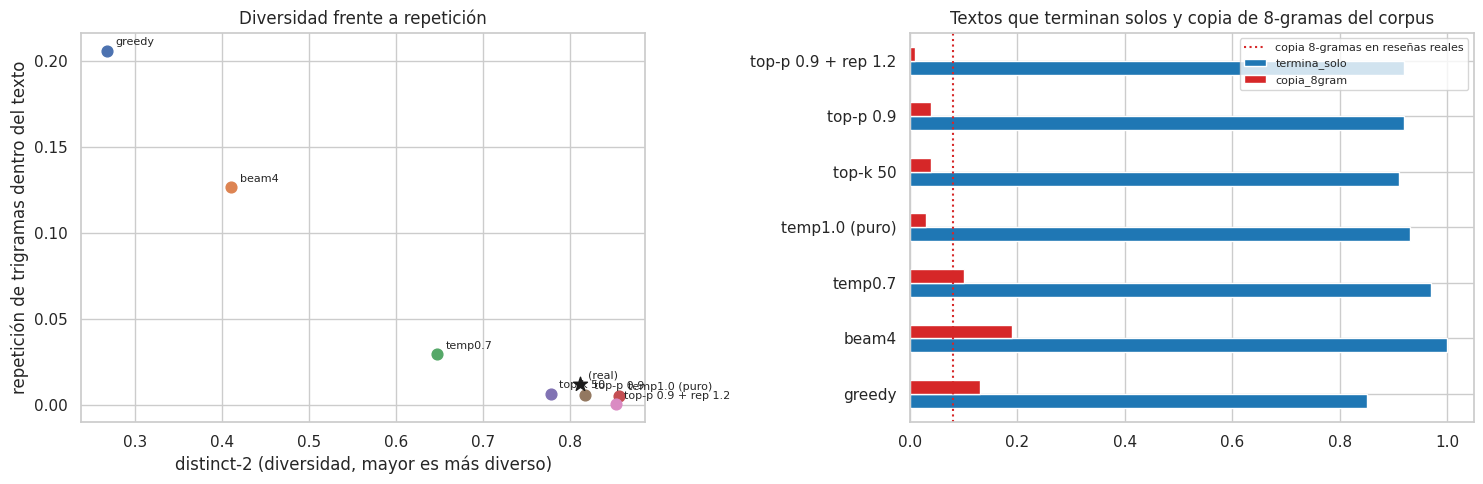

Un ejemplo por configuración (mismo prompt):
  [greedy] (terminó) 'distinto tono de voz\n\nel tono de voz es muy bueno, pero el tono de voz es muy bajo, no se escucha bien, y el sonido es muy bajo, no se escucha bien.'
  [beam4] (terminó) 'distinto tono de voz\n\nel tono de voz es muy bueno, pero el tono de voz no es muy bueno.'
  [temp0.7] (terminó) 'distinto tono de voz\n\nEs un pack de tres auriculares con los que me gusta mucho el audio. Todos los cuales son de mi funda OEM.. con lo que no estropea nada. Con esta funda es fácil de instalar y se nota que no hay demasiada diferencia.'
  [temp1.0 (puro)] (terminó) 'distinto tono de film\n\nLo compre para espejo salon jamon, pero parece hermético no se abren bien el exterior de mi ni muy limpio ni con muy poca luz, el de 24 h y este es un huevo chino'
  [top-k 50] (terminó) 'distinto tono de su marca\n\nel pack se queda grande y los colores muy bonitos'
  [top-p 0.9] (terminó) 'distinto tono de film\n\nLo compre para mi mujer y le gust

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
for name, r in met.iterrows():
    real = name == '(real)'
    ax.scatter(r['distinct2'], r['repeticion'], s=110 if real else 60, marker='*' if real else 'o', color='k' if real else None, zorder=3)
    ax.annotate(name, (r['distinct2'], r['repeticion']), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('distinct-2 (diversidad, mayor es más diverso)'); ax.set_ylabel('repetición de trigramas dentro del texto'); ax.set_title('Diversidad frente a repetición')
gen_only = met.drop(index='(real)')
gen_only[['termina_solo', 'copia_8gram']].plot.barh(ax=axes[1], color=['tab:blue', 'tab:red'])
axes[1].axvline(met.loc['(real)', 'copia_8gram'], color='tab:red', ls=':', label='copia 8-gramas en reseñas reales')
axes[1].set_title('Textos que terminan solos y copia de 8-gramas del corpus'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('Un ejemplo por configuración (mismo prompt):')
for name, (txts, fin) in gen_store.items():
    print(f'  [{name}] {"(terminó)" if fin[0] else "(cortado)"} {txts[0]!r}')

### 8.1 Lectura del experimento 2

| Configuración | distinct-1 | distinct-2 | Repetición de trigramas | Palabras | Copia 8-gramas | Termina solo |
|---|---|---|---|---|---|---|
| greedy | 0.111 | 0.268 | 0.206 | 23.5 | 0.13 | 0.85 |
| beam 4 | 0.167 | 0.411 | 0.127 | 13.0 | 0.19 | 1.00 |
| temperatura 0.7 | 0.237 | 0.647 | 0.030 | 24.9 | 0.10 | 0.97 |
| temperatura 1.0 | 0.371 | 0.857 | 0.0056 | 27.7 | 0.03 | 0.93 |
| top-k 50 | 0.287 | 0.778 | 0.0066 | 27.8 | 0.04 | 0.91 |
| top-p 0.9 | 0.311 | 0.818 | 0.0062 | 30.0 | 0.04 | 0.92 |
| top-p 0.9 + penalización 1.2 | 0.330 | 0.853 | 0.0007 | 30.0 | 0.01 | 0.92 |
| reseñas reales | 0.330 | 0.811 | 0.0125 | 31.3 | 0.08 | |

**Greedy y beam search repiten.** En greedy, en promedio 20.6 % de los trigramas de cada texto son repeticiones, y y su distinct-2 (0.268) es un tercio del real; beam search escribe reseñas de 13 palabras, la mitad de la longitud real, y es la que más copia del corpus (0.19), porque maximizar la probabilidad conduce a las fórmulas más frecuentes del entrenamiento. **El muestreo puro (temperatura 1.0)** tiene la mayor diversidad (distinct-2 0.857, por encima de la real) y poca copia (0.03), porque elige tokens de la cola de la distribución. Las métricas de esta tabla no miden coherencia, pero la muestra de la salida la deja ver: con el mismo prompt escribe *"Lo compre para espejo salon jamon… y este es un huevo chino"*. **Top-k y top-p** recortan esa cola: top-p 0.9 entrega más diversidad y más palabras que top-k 50 con el mismo nivel de repetición, porque su corte se adapta a la incertidumbre de cada paso.

**La penalización de repetición** baja la repetición de trigramas de 0.0062 a 0.0007 y la copia de 8-gramas de 0.04 a 0.01, ambas por debajo de las reseñas reales (0.0125 y 0.08): corrige de más. Frente a la fila real, top-p 0.9 sin penalización queda más cerca en distinct-2 (0.818 frente a 0.811), repetición y copia; la penalización solo acerca distinct-1 (0.330 frente a 0.330), y en longitud las dos empatan (30.0 frente a 31.3 palabras). Por eso el experimento 3 usa **top-p 0.9**, la configuración cuyo texto se parece más al real, y el experimento 4 usa además **top-p 0.9 con penalización 1.2**, la variante que menos repite y menos copia del corpus de entrenamiento. La hipótesis 2 se confirma en diversidad y repetición; la pérdida de coherencia del muestreo puro se observa en las muestras y no tiene una métrica propia en este notebook.

## 9. Experimento 3: generación controlada por calificación

**Pregunta:** si el generador aprende que cada reseña empieza con `Calificación: N estrellas`, ¿el sentimiento del texto generado sigue a N?

Ajustamos un tercer modelo con la receta corregida sobre las mismas 30 000 reseñas, pero anteponiendo a cada texto su código de control. Para generar, escribimos solo el código (por ejemplo `Calificación: 1 estrellas\n`) y dejamos que el modelo escriba el título y el cuerpo. La decodificación es top-p 0.9 sin penalización (la configuración más cercana a las reseñas reales en el experimento 2), con 100 textos por calificación. Evaluamos con el juez: porcentaje de textos cuya clase coincide con la pedida (1–2 negativo, 3 neutro, 4–5 positivo), estrellas esperadas frente a las pedidas y correlación de Spearman. La fila de referencia es el mismo juez aplicado a reseñas reales de esa calificación e indica cuánto acierta el juez con texto humano.

In [21]:
PREFIX = lambda n: f'Calificación: {n} estrellas\n'
set_seed(SEED); tok_ct, model_ct = load_lm('fixed')
MAX_LEN_CT = MAX_LEN + 8          # margen para el prefijo, de modo que la reseña conserve su longitud efectiva
ctrl_tr = [PREFIX(s) + t for s, t in zip(gen_df['stars'], gen_df['text'])]
ctrl_va = [PREFIX(s) + t for s, t in zip(val_sub['stars'], val_sub['text'])]
seq_c_tr, _ = encode_texts(tok_ct, ctrl_tr, MAX_LEN_CT, add_eos=True)
seq_c_va, _ = encode_texts(tok_ct, ctrl_va, MAX_LEN_CT, add_eos=True)
print(repr(ctrl_tr[0][:120]))
print('Tokens del prefijo:', len(tok_ct(PREFIX(5), add_special_tokens=False)['input_ids']))
model_ct, hist_c = finetune('controlada', tok_ct, model_ct, seq_c_tr, seq_c_va)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

'Calificación: 3 estrellas\nEl drone funciona a la perfeccion\n\nMini usb cable de carga defectuoso por lo cual se estropear'
Tokens del prefijo: 6
{'loss': '3.304', 'grad_norm': '1.674', 'learning_rate': '3.751e-05', 'epoch': '1'}
{'eval_loss': '3.06', 'eval_runtime': '1.526', 'eval_samples_per_second': '1311', 'eval_steps_per_second': '41.29', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.939', 'grad_norm': '1.72', 'learning_rate': '2.501e-05', 'epoch': '2'}
{'eval_loss': '2.999', 'eval_runtime': '1.559', 'eval_samples_per_second': '1283', 'eval_steps_per_second': '40.41', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

{'loss': '2.801', 'grad_norm': '1.81', 'learning_rate': '1.333e-08', 'epoch': '4'}
{'eval_loss': '2.98', 'eval_runtime': '1.527', 'eval_samples_per_second': '1310', 'eval_steps_per_second': '41.27', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '250.1', 'train_samples_per_second': '479.8', 'train_steps_per_second': '15', 'train_loss': '2.973', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[controlada] entrenado en 4.2 min


In [22]:
# ¿Qué cambia en la distribución del primer token cuando cambia el prefijo? Los 6 tokens más probables por calificación.
model_ct.eval()
tabla = {}
for s in range(1, 6):
    ids = torch.tensor([tok_ct(PREFIX(s), add_special_tokens=False)['input_ids']], device=DEVICE)
    with torch.no_grad(): p = torch.softmax(model_ct(input_ids=ids).logits[0, -1].float(), -1)
    top = p.topk(6)
    tabla[f'{s}★'] = [f'{tok_ct.decode([i]).strip()!r} {v:.2f}' for v, i in zip(top.values.tolist(), top.indices.tolist())]
pd.DataFrame(tabla)

,1★,2★,3★,4★,5★
0,'No' 0.22,'No' 0.18,'No' 0.09,'Buena' 0.08,'Muy' 0.10
1,'Mala' 0.03,'Muy' 0.02,'Muy' 0.03,'Muy' 0.06,'Buena' 0.05
2,'Mal' 0.03,'Se' 0.02,'Buena' 0.03,'Buen' 0.06,'Perfecto' 0.04
3,'D' 0.03,'D' 0.02,'Bien' 0.03,'Bien' 0.03,'Buen' 0.04
4,'Muy' 0.02,'Mala' 0.02,'Buen' 0.02,'Cu' 0.02,'Genial' 0.02
5,'no' 0.02,'Re' 0.02,'Re' 0.02,'Calidad' 0.02,'Per' 0.02


In [23]:
res, gen_ct = [], {}
for s in range(1, 6):
    prompt = tok_ct(PREFIX(s), add_special_tokens=False)['input_ids']
    set_seed(SEED + s)
    txts, fin = generate_batch(model_ct, tok_ct, [prompt] * N_PER_STAR, **GEN_TOPP)
    bodies = [t.split('\n', 1)[1] if '\n' in t else t for t in txts]        # quitamos la línea del código de control
    req = STAR2CLS[s]
    pc, es = judge_class(bodies), judge_stars(bodies)
    res.append({'pedido': f'{s}★', 'clase_ok': float(np.mean(pc == req)), 'estrellas_juez': float(es.mean()),
                'clase_ok (real)': JUDGE_REAL.loc[s, 'exactitud'], 'estrellas_juez (real)': JUDGE_REAL.loc[s, 'estrellas_juez'],
                'termina_solo': float(np.mean(fin)), 'distinct2': distinct_n(bodies, 2)})
    gen_ct[s] = (bodies, pc, es)
tab3 = pd.DataFrame(res).set_index('pedido').round(3)
allreq = np.concatenate([[s] * N_PER_STAR for s in range(1, 6)])
allest = np.concatenate([gen_ct[s][2] for s in range(1, 6)])
allcls = np.concatenate([gen_ct[s][1] for s in range(1, 6)])
overall = float(np.mean(allcls == np.array([STAR2CLS[s] for s in allreq])))
overall_real = float(real_judge['clase_ok'].mean())
rho = spearmanr(allreq, allest)[0]
print(f'Controlabilidad global (clase pedida = clase del juez): {overall:.3f} | reseñas reales: {overall_real:.3f} | Spearman(estrellas pedidas, estrellas del juez) = {rho:.3f}')
tab3

Controlabilidad global (clase pedida = clase del juez): 0.686 | reseñas reales: 0.741 | Spearman(estrellas pedidas, estrellas del juez) = 0.739


,clase_ok,estrellas_juez,clase_ok (real),estrellas_juez (real),termina_solo,distinct2
pedido,,,,,,
1★,0.85,1.976,0.916,1.667,0.90,0.775
2★,0.69,2.301,0.667,2.295,0.94,0.778
3★,0.34,2.899,0.503,2.939,0.95,0.777
4★,0.69,3.747,0.712,3.790,0.93,0.742
5★,0.86,4.165,0.905,4.271,0.96,0.775


Sin control (clases según el juez): {'negativo': 0.41, 'positivo': 0.36, 'neutro': 0.23} | corpus real: negativo 0.4, neutro 0.2, positivo 0.4


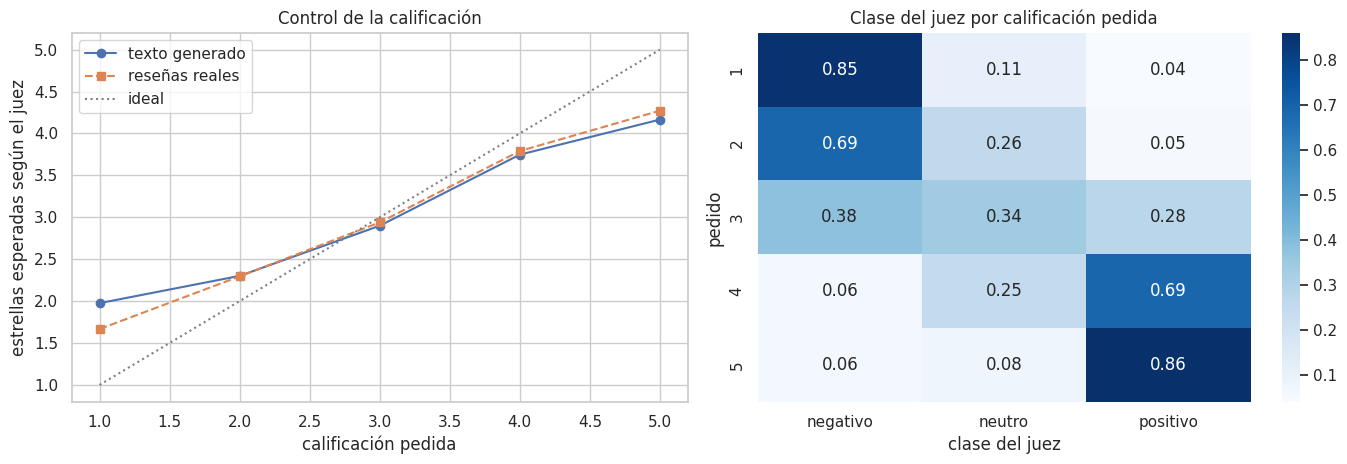

--- 1★ (2 ejemplos) ---
  [neutro, juez 3.1★] 'No se ajusta bien\n\nFunciona bien. Todo correcto, tiene 4 marchas y hay que hacer algunas compresas. Pero el volante no encaja bien en el móvil.'
  [negativo, juez 1.3★] '¡Uf! No valen para nada\n\nMuy mala calidad. Han desaparecido los asas y los puntitos de la posición para colocar la cinta de agua en el mango.'
--- 3★ (2 ejemplos) ---
  [neutro, juez 2.6★] 'bonito pero mal práctico\n\nBonito pero un poco caro. No lo volvería a comprar'
  [neutro, juez 2.4★] 'Tiene mejor terminación que el original\n\nDespués de muchos meses de uso ya no la puedo utilizar ya que la cobertura es mala y me quedé con ella un día de lluvia.'
--- 5★ (2 ejemplos) ---
  [positivo, juez 4.9★] 'Me encantan\n\nMuy cómodo y recomendable la mayoría de veces.'
  [neutro, juez 3.8★] 'Extensión\n\nMe ha gustado. Y es original. Tiene su sensibilidad,parece antiguo. Su precio es correcto'

Fallos: pedido 5★ y el juez dice negativo | pedido 1★ y el juez dice positivo
  [

In [24]:
# Referencia sin control: el generador corregido del experimento 1 con top-p 0.9 (prompts reales) reparte las clases como el corpus?
unc_txt = gen_store['top-p 0.9'][0]
unc = pd.Series(judge_class(unc_txt)).map(ID2SENT).value_counts(normalize=True).round(3)
print('Sin control (clases según el juez):', unc.to_dict(), '| corpus real: negativo 0.4, neutro 0.2, positivo 0.4')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ax = axes[0]
ax.plot(range(1, 6), tab3['estrellas_juez'], '-o', label='texto generado'); ax.plot(range(1, 6), tab3['estrellas_juez (real)'], '--s', label='reseñas reales')
ax.plot([1, 5], [1, 5], ':', color='gray', label='ideal'); ax.set_xlabel('calificación pedida'); ax.set_ylabel('estrellas esperadas según el juez'); ax.legend(); ax.set_title('Control de la calificación')
conf = pd.crosstab(pd.Series(allreq, name='pedido'), pd.Series(allcls, name='clase del juez').map(ID2SENT), normalize='index')[['negativo', 'neutro', 'positivo']]
sns.heatmap(conf, annot=True, fmt='.2f', cmap='Blues', ax=axes[1]); axes[1].set_title('Clase del juez por calificación pedida')
plt.tight_layout(); plt.show()

for s in (1, 3, 5):
    print(f'--- {s}★ (2 ejemplos) ---')
    for b, c, e in list(zip(*gen_ct[s]))[:2]: print(f'  [{ID2SENT[c]}, juez {e:.1f}★] {b!r}')
print('\nFallos: pedido 5★ y el juez dice negativo | pedido 1★ y el juez dice positivo')
for s, bad in [(5, 0), (1, 2)]:
    fails = [(b, e) for b, c, e in zip(*gen_ct[s]) if c == bad][:2]
    for b, e in fails: print(f'  [{s}★ pedido, juez {e:.1f}★] {b!r}')

### 9.1 Lectura del experimento 3

| Calificación pedida | Obedece (generado) | Obedece (reales, referencia del juez) | Estrellas medias del juez (generado) | Estrellas medias del juez (reales) |
|---|---|---|---|---|
| 1 ★ | 0.85 | 0.916 | 1.976 | 1.667 |
| 2 ★ | 0.69 | 0.667 | 2.301 | 2.295 |
| 3 ★ | 0.34 | 0.503 | 2.899 | 2.939 |
| 4 ★ | 0.69 | 0.712 | 3.747 | 3.790 |
| 5 ★ | 0.86 | 0.905 | 4.165 | 4.271 |

La controlabilidad global es **0.686** frente a 0.741 en las reseñas reales, y la correlación de Spearman entre la calificación pedida y las estrellas que estima el juez es **0.739**. El modelo obedece con claridad en los extremos (0.85 y 0.86), cerca de la referencia del juez, y pierde terreno en el centro (0.34 en 3 estrellas frente a 0.503 en las reales): la calificación de 3 estrellas mezcla elogio y queja, y también al juez le cuesta reconocerla. La brecha respecto a la referencia es de 5 a 7 puntos en 1 y 5 estrellas y de 16 en 3 estrellas. La referencia funciona como un techo aproximado: en 2 estrellas el texto generado la supera (0.69 frente a 0.667), señal de que un texto generado puede ser más prototípico que uno humano y más fácil de clasificar. Con 100 textos por calificación, el intervalo de confianza del 95 % de cada proporción es de unos ±7 a ±9 puntos, así que las brechas de 1 y 5 estrellas están en el límite de lo que esta muestra permite distinguir. La hipótesis 3 se confirma.

El prefijo desplaza el primer token: con 1 estrella arranca con *No* (0.22); con 5 estrellas con *Muy* (0.10), *Buena* (0.05) y *Perfecto* (0.04); con 4 estrellas con *Buena* (0.08). Sin control, el generador produce una mezcla de 0.41 negativo, 0.23 neutro y 0.36 positivo, frente al 40/20/40 de las etiquetas del corpus. La comparación es aproximada: el juez de tres clases se entrenó con pesos de clase balanceados, que favorecen la clase neutra, así que el exceso de neutro (0.23 frente a 0.20) puede venir del juez tanto como del generador. Los fallos son de dos tipos: pedidos de 5 estrellas que salen negativos (*"Horrible…"*) y pedidos de 1 estrella que salen positivos (*"Es lo que quería"*). En ambos casos el texto generado tiene el signo contrario al pedido según el juez; el prefijo orienta la distribución y no la fija. El segundo fallo de 1 estrella, un texto en mayúsculas sin sentido, muestra además que el juez asigna una calificación aunque el texto sea incoherente.

## 10. Experimento 4: ¿se puede detectar el texto generado?

**Pregunta:** un detector sencillo, ¿distingue una reseña real de una generada, y depende eso de la estrategia de decodificación?

Tomamos `N_DETECT` reseñas reales del conjunto de **prueba** (que ningún modelo vio), usamos sus primeros 4 tokens como prompt, y generamos con el generador corregido tres versiones: greedy, muestreo puro a temperatura 1 y top-p 0.9 con penalización de repetición. Contra cada versión entrenamos un detector (TF-IDF de palabras y bigramas + regresión logística) que distingue "real" de "generada" sobre las mismas reseñas, con validación cruzada de 5 particiones **agrupadas por reseña** (el texto real y el generado que comparten prompt caen siempre en la misma partición). Como control, un detector que solo usa la longitud del texto mide cuánto de la detección es un artefacto de longitud.

In [25]:
det_prompts, det_real = build_prompts(test_df, N_DETECT)
DET_STRATS = ['greedy', 'temp1.0 (puro)', 'top-p 0.9 + rep 1.2']
det_gen = {}
for name in DET_STRATS:
    set_seed(SEED)
    det_gen[name], _ = generate_batch(model_f, tok_f, det_prompts, **DECODING[name])

def cv_auc(real, gen, featurizer):
    X = real + gen; y = np.r_[np.zeros(len(real)), np.ones(len(gen))]
    groups = np.r_[np.arange(len(real)), np.arange(len(gen))]
    n_splits = min(5, len(real))
    p = cross_val_predict(featurizer, X, y, cv=GroupKFold(n_splits=n_splits), groups=groups, method='predict_proba')[:, 1]
    return roc_auc_score(y, p), accuracy_score(y, p > 0.5)

from sklearn.preprocessing import FunctionTransformer
length_feat = make_pipeline(FunctionTransformer(lambda xs: np.array([[len(words(t)), len(t)] for t in xs])), LogisticRegression(max_iter=1000))
text_feat = lambda: make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), LogisticRegression(max_iter=1000, C=3.0))

rows = {}
for name in DET_STRATS:
    a, acc_ = cv_auc(det_real, det_gen[name], text_feat())
    la, _ = cv_auc(det_real, det_gen[name], length_feat)
    rows[name] = {'AUC (texto)': a, 'exactitud (texto)': acc_, 'AUC (solo longitud)': la}
tab4 = pd.DataFrame(rows).T.round(3)
tab4

,AUC (texto),exactitud (texto),AUC (solo longitud)
greedy,0.964,0.896,0.836
temp1.0 (puro),0.540,0.546,0.508
top-p 0.9 + rep 1.2,0.546,0.538,0.562


In [26]:
# Palabras que delatan al texto sintético (y al real) en cada estrategia: coeficientes de la regresión logística sobre unigramas
for name in DET_STRATS:
    X = det_real + det_gen[name]; y = np.r_[np.zeros(len(det_real)), np.ones(len(det_gen[name]))]
    vec = TfidfVectorizer(min_df=3, sublinear_tf=True); Xv = vec.fit_transform(X)
    clf = LogisticRegression(max_iter=1000, C=3.0).fit(Xv, y)
    terms = np.array(vec.get_feature_names_out()); o = np.argsort(clf.coef_[0])
    print(f'{name:<22} más "real": {list(terms[o[:10]])}\n{"":<22} más "sintético": {list(terms[o[::-1][:10]])}')
print('\nEjemplo real vs generado (mismo prompt):')
print('  real     :', repr(det_real[0]));
for name in DET_STRATS: print(f'  {name:<10}:', repr(det_gen[name][0]))

greedy                 más "real": ['al', 'en', 'como', 'las', 'los', 'que', 'por', 'su', 'aunque', 'más']
                       más "sintético": ['es', 'muy', 'no', 'puede', 'esperaba', 'pero', 'producto', 'nada', 'gustado', 'pantalla']
temp1.0 (puro)         más "real": ['días', 'sin', 'bordes', 'perfectamente', 'montar', 'transporte', 'su', 'plástico', 'rapidez', 'malo']
                       más "sintético": ['pronto', 'quería', 'pude', 'tan', 'demasiado', 'fecha', 'creo', 'hace', 'mal', 'cuando']
top-p 0.9 + rep 1.2    más "real": ['luego', 'unico', 'euros', 'gustado', 'vale', 'al', 'rapidez', 'sin', 'montaje', 'me']
                       más "sintético": ['del', 'hace', 'excelente', 'hacer', 'caro', 'hijo', 'con', 'ha', 'esperaba', 'tenido']

Ejemplo real vs generado (mismo prompt):
  real     : 'Cubo gran capacidad y buen transporte\n\nLas bolsas que se venden de 120 litros, que se suponen que van bien al cubo. Ni por asomo. La boca del cubo es mucho más grande que las bolsas

### 10.1 Lectura del experimento 4

| Estrategia | AUC del detector | Exactitud | AUC solo con longitud |
|---|---|---|---|
| greedy | 0.964 | 0.896 | 0.836 |
| temperatura 1.0 | 0.540 | 0.546 | 0.508 |
| top-p 0.9 + penalización 1.2 | 0.546 | 0.538 | 0.562 |

El texto de greedy se detecta con un AUC de **0.964**. Parte de esa señal viene de la longitud (un detector que solo ve el número de palabras alcanza 0.836), y el resto de su vocabulario: greedy se apoya en las palabras de las fórmulas evaluativas (*es*, *muy*, *no*, *pero*, *esperaba*, *producto*, *nada*), mientras que las reseñas reales usan más preposiciones, artículos y conectores (*al*, *en*, *como*, *las*, *los*, *por*, *su*, *aunque*), propios de frases más largas y descriptivas. Con muestreo puro y con top-p más penalización, el detector queda en **0.54 y 0.55**, casi al azar. La hipótesis 4 se confirma y resulta más fuerte de lo esperado: incluso el muestreo puro engaña a este detector. Las dos cifras no son del todo independientes: con la misma semilla y el mismo prompt, las dos estrategias pueden producir el mismo texto, como ocurre en el ejemplo de la salida.

Este resultado dice dos cosas. Un detector de TF-IDF con regresión logística, entrenado aquí con solo 800 textos (400 reales y 400 generados), es una vara baja, y un detector con embeddings o un modelo de lenguaje probablemente rendiría mucho mejor con el texto muestreado. Aun así, el texto que produce el generador con la configuración que menos repite y menos copia (top-p con penalización) no tiene marcas léxicas ni de longitud que un clasificador sencillo pueda usar, y en un sistema de moderación esa señal no alcanza.

## 11. Demo interactiva

Elige una calificación, escribe (o no) el comienzo del título, ajusta la temperatura y el top-p, y el modelo controlado escribe tres reseñas. Junto a cada texto aparece lo que opina el juez. Funciona en Colab con `ipywidgets`; si no están disponibles, la celda imprime ejemplos fijos.

In [27]:
def generar(stars, inicio='', temperature=0.9, top_p=0.9, n=3):
    ids = tok_ct(PREFIX(stars) + inicio, add_special_tokens=False)['input_ids']
    txts, _ = generate_batch(model_ct, tok_ct, [ids] * n, max_new=MAX_NEW + 40, do_sample=True, temperature=temperature, top_k=0, top_p=top_p)
    cuerpos = [t.split('\n', 1)[1] if '\n' in t else t for t in txts]
    cls, est = judge_class(cuerpos), judge_stars(cuerpos)
    return [f'[juez: {ID2SENT[c]}, {e:.1f}★] {b}' for b, c, e in zip(cuerpos, cls, est)]

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    dd = widgets.Dropdown(options=[1, 2, 3, 4, 5], value=5, description='Estrellas')
    ti = widgets.Text(value='', placeholder='Comienzo del título (opcional)', description='Inicio', layout=widgets.Layout(width='60%'))
    ts = widgets.FloatSlider(value=0.9, min=0.5, max=1.3, step=0.05, description='Temperatura')
    ps = widgets.FloatSlider(value=0.9, min=0.5, max=1.0, step=0.05, description='top-p')
    btn = widgets.Button(description='Generar', button_style='primary'); out = widgets.Output()
    def _click(_):
        with out:
            clear_output()
            for t in generar(dd.value, ti.value, ts.value, ps.value): print(t); print('-' * 70)
    btn.on_click(_click); display(widgets.VBox([dd, ti, ts, ps, btn, out])); _click(None)
except Exception as e:
    print('ipywidgets no disponible, ejemplos fijos:', e)
    for s in (1, 3, 5):
        print(f'--- {s}★ ---'); print(generar(s, n=1)[0])

## 12. Conclusiones

1. **Receta de fine-tuning.** El EOS explícito y un token de relleno propio hacen que el modelo aprenda a terminar: 92 % de los textos terminan solos frente a 0 % con la receta del guía, y la probabilidad de EOS en un final natural pasa de 4.9e-9 a 0.310. El costo es de +0.8 de perplejidad (29.77 a 30.57). El fine-tuning completo baja la perplejidad del modelo base de 282 a cerca de 30 en 4 épocas, sin sobreajuste.
2. **Decodificación.** Greedy y beam search producen texto repetitivo (en greedy, 20.6 % de los trigramas de cada texto se repiten) o corto (13 palabras en beam search); el muestreo puro maximiza la diversidad y, en las muestras, pierde coherencia. Top-p 0.9 queda más cerca de la referencia real (distinct-2 0.818 frente a 0.811, 30.0 frente a 31.3 palabras) y es la configuración del experimento 3; con una penalización de repetición de 1.2, la repetición y la copia del corpus caen por debajo de las reales, y esa variante entra en el experimento 4.
3. **Control por calificación.** Un prefijo de texto basta para dirigir el sentimiento: 0.85 y 0.86 de obediencia en 1 y 5 estrellas, cerca de la referencia del juez sobre reseñas reales (0.916 y 0.905), Spearman de 0.739 y una controlabilidad global de 0.686 frente a 0.741. El centro es la zona débil (0.34 en 3 estrellas frente a 0.503 de las reales).
4. **Detección.** Greedy se detecta con un AUC de 0.964, en buena parte por su longitud (0.836 con esa sola variable) y por su vocabulario de fórmulas evaluativas; el muestreo puro y top-p con penalización quedan en 0.54 y 0.55 frente a un detector léxico entrenado con 800 textos. Esto muestra el doble uso de la técnica: sirve para generar datos de prueba y aumento de datos, y para producir reseñas falsas difíciles de filtrar con métodos sencillos.
5. **Riesgos y límites.** El juez es un clasificador de TF-IDF con accuracy de 0.741 y F1 macro de 0.700, y sus errores entran en todas las cifras de controlabilidad. Entrenamos un solo modelo con una sola semilla, los prompts salen de reseñas reales de validación, las muestras son de 100 textos por configuración en los experimentos 1 y 2, 100 por calificación en el 3 y 400 por estrategia en el 4 (las diferencias de pocos puntos no son concluyentes) y la copia de 8-gramas es una medida gruesa de memorización. La diversidad y la repetición se midieron con métricas; la coherencia, solo con lectura de muestras, y no hubo evaluación humana.
6. **Lo que haríamos después.** Ajustar con LoRA un modelo más grande, controlar aspectos del producto (envío, calidad, precio) además de la calificación, entrenar un detector basado en embeddings o en un modelo de lenguaje, medir la coherencia con la perplejidad del texto generado según un modelo de referencia, y hacer una evaluación humana ciega que compare reseñas reales y generadas.